In [13]:
import pandas as pd
import matplotlib.pyplot as plt #import plotting package
#render plotting automatically
%matplotlib inline
import matplotlib as mpl #additional plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high resolution figures
mpl.rcParams['font.size'] = 4 #font size for figures
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [2]:
df = pd.read_csv('df_cleaned.csv')

In [6]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split\
                                          (df['LIMIT_BAL'].values.reshape(-1,1),\
                                            df['default payment next month'].values,\
                                           test_size=0.2,\
                                           random_state=24)

In [9]:
example_lr = LogisticRegression(C=0.1, class_weight=None,
                                dual=False, fit_intercept=True,
                                intercept_scaling=1, max_iter=100,
                                multi_class='auto', n_jobs=None,
                                penalty='l2', random_state=None,
                                solver='liblinear', tol=0.0001,
                                verbose=0, warm_start=False)

In [10]:
example_lr.fit(X_train_2, y_train_2)

/opt/anaconda3/envs/dspwp2/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=0.1, multi_class='auto', solver='liblinear')

In [11]:
y_test_2_pred_proba = example_lr.predict_proba(X_test_2)

In [14]:
metrics.roc_auc_score(y_test_2, y_test_2_pred_proba[:,1])

np.float64(0.6201990844642832)

Text(0.5, 1.0, 'ROC curve for logistic regression with LIMIT_BAL feature')

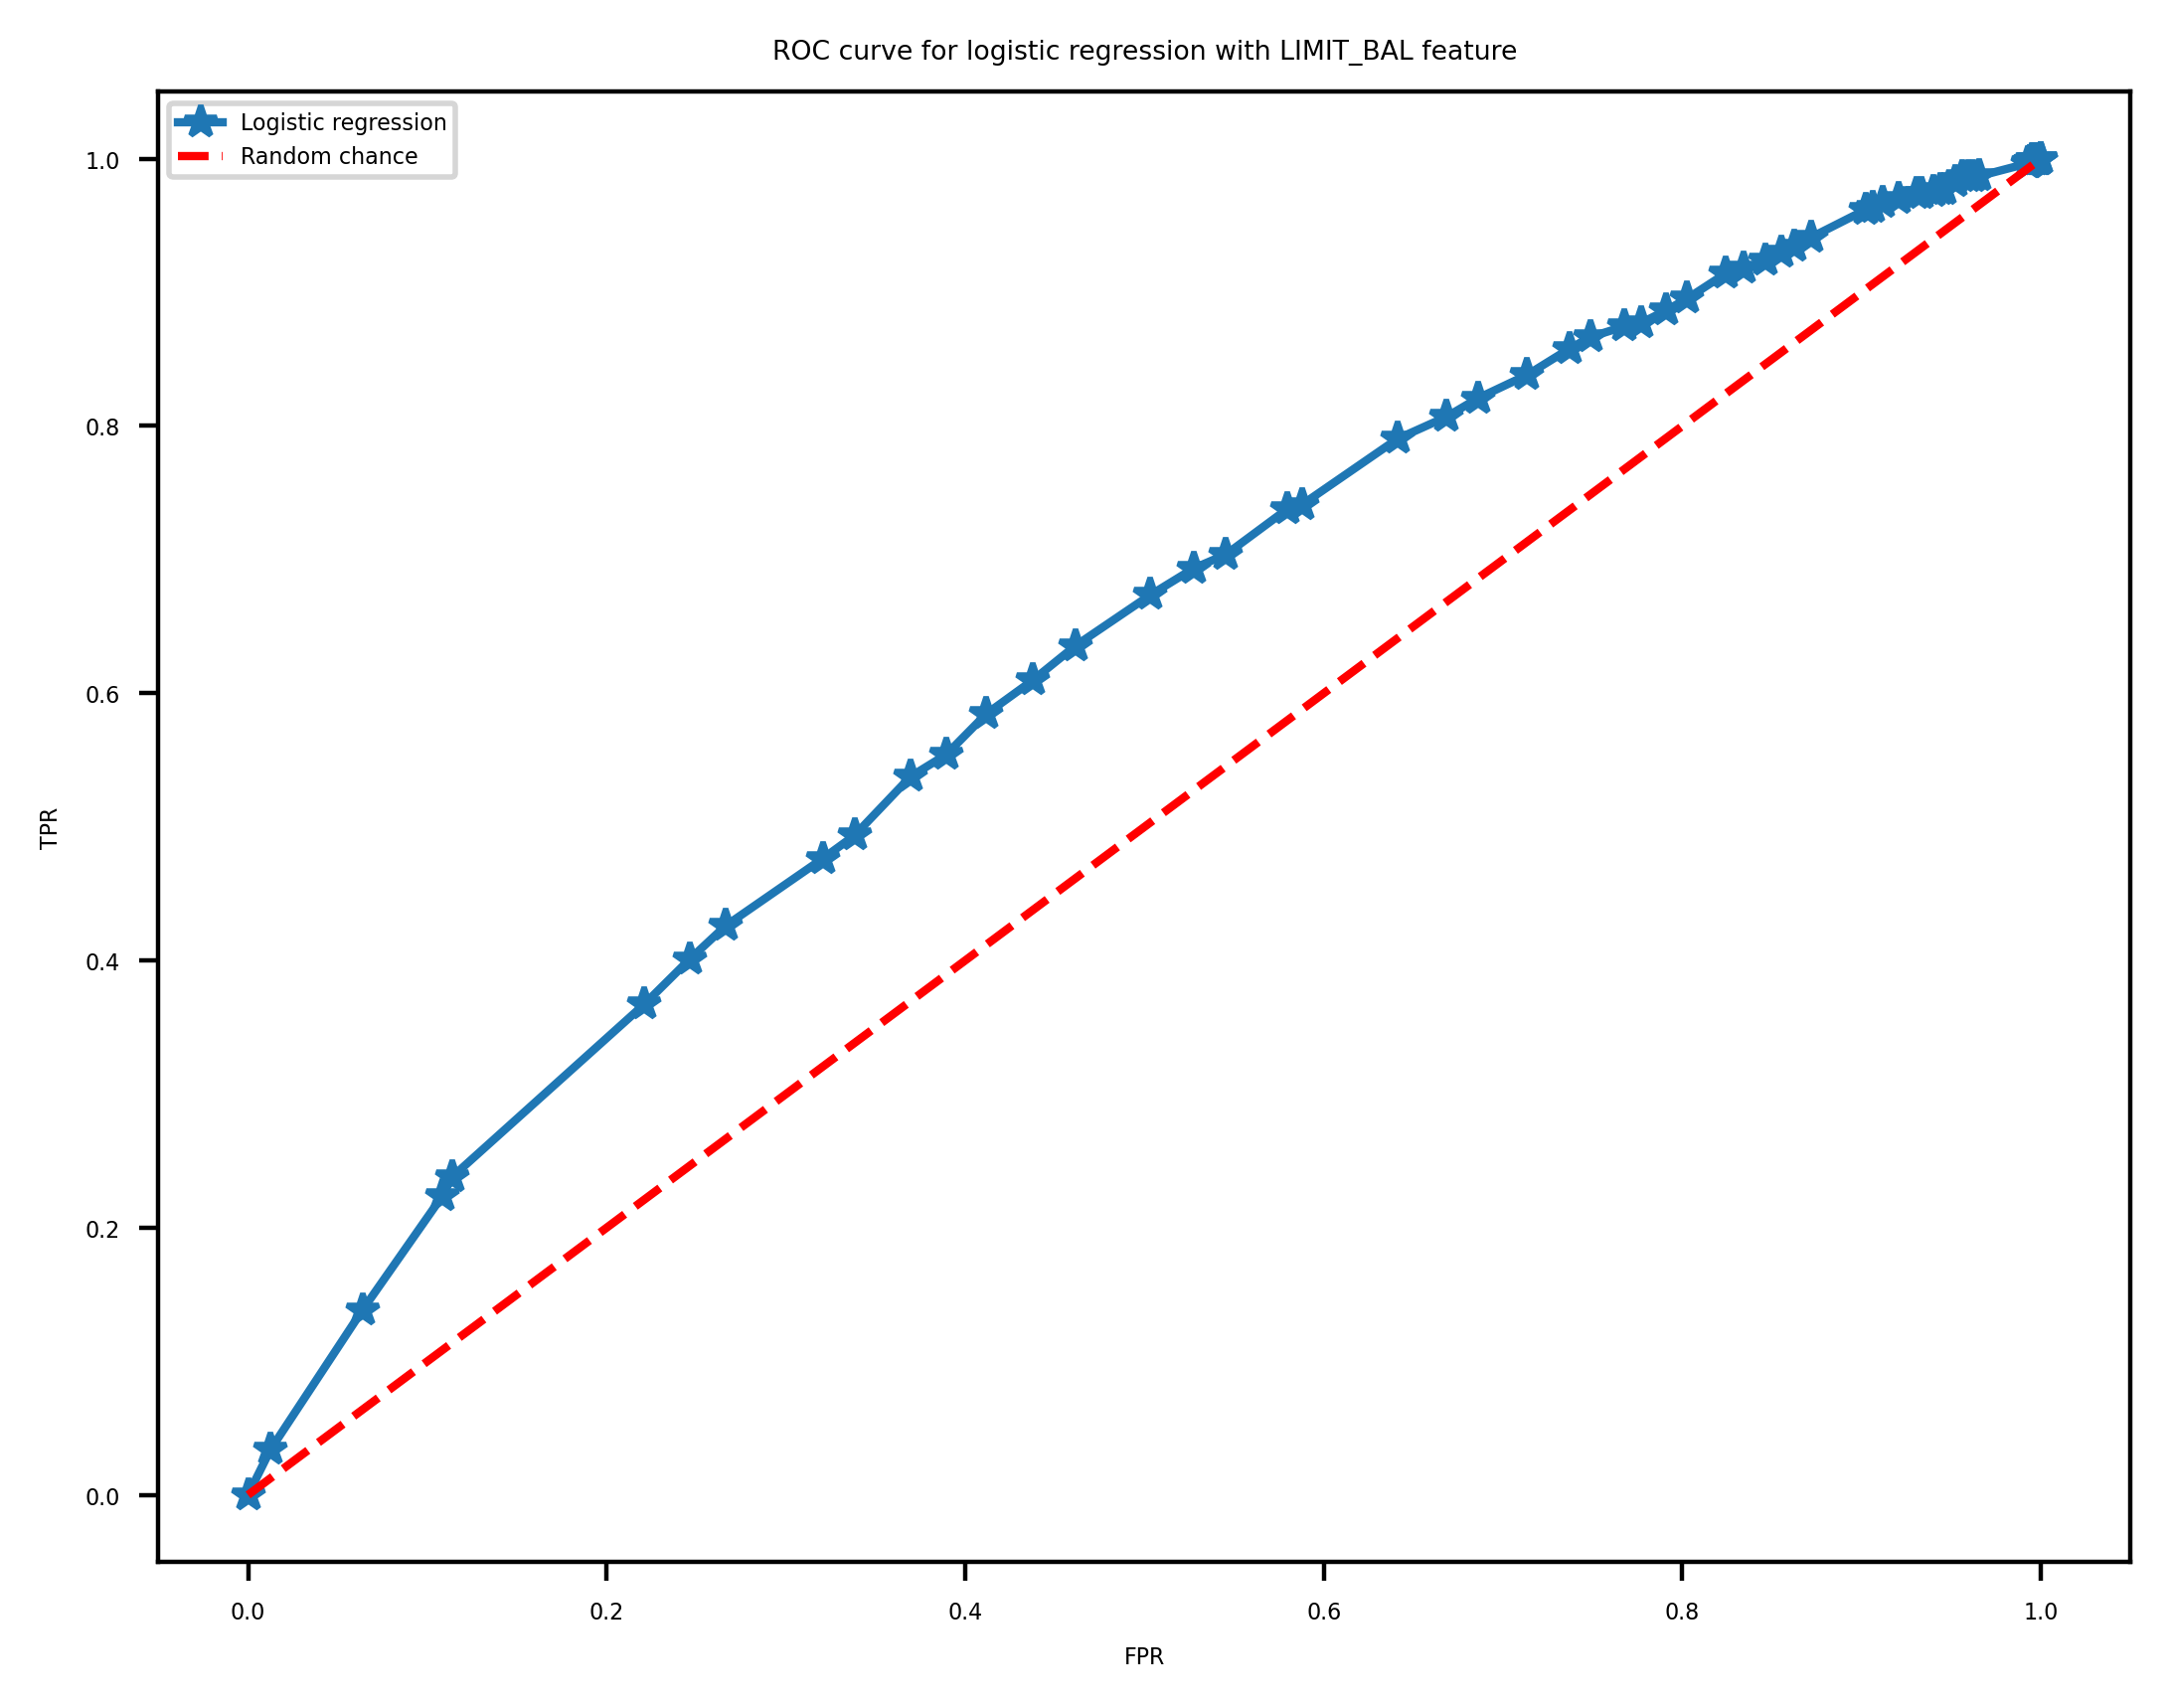

In [15]:
# Plot the ROC curve
fpr_2, tpr_2, thresholds_2 = metrics.roc_curve\
                             (y_test_2, \
                              y_test_2_pred_proba[:,1])
plt.plot(fpr_2, tpr_2, '*-')
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(['Logistic regression', 'Random chance'])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for logistic regression with '\
          'LIMIT_BAL feature')

(0.0, 1.0)

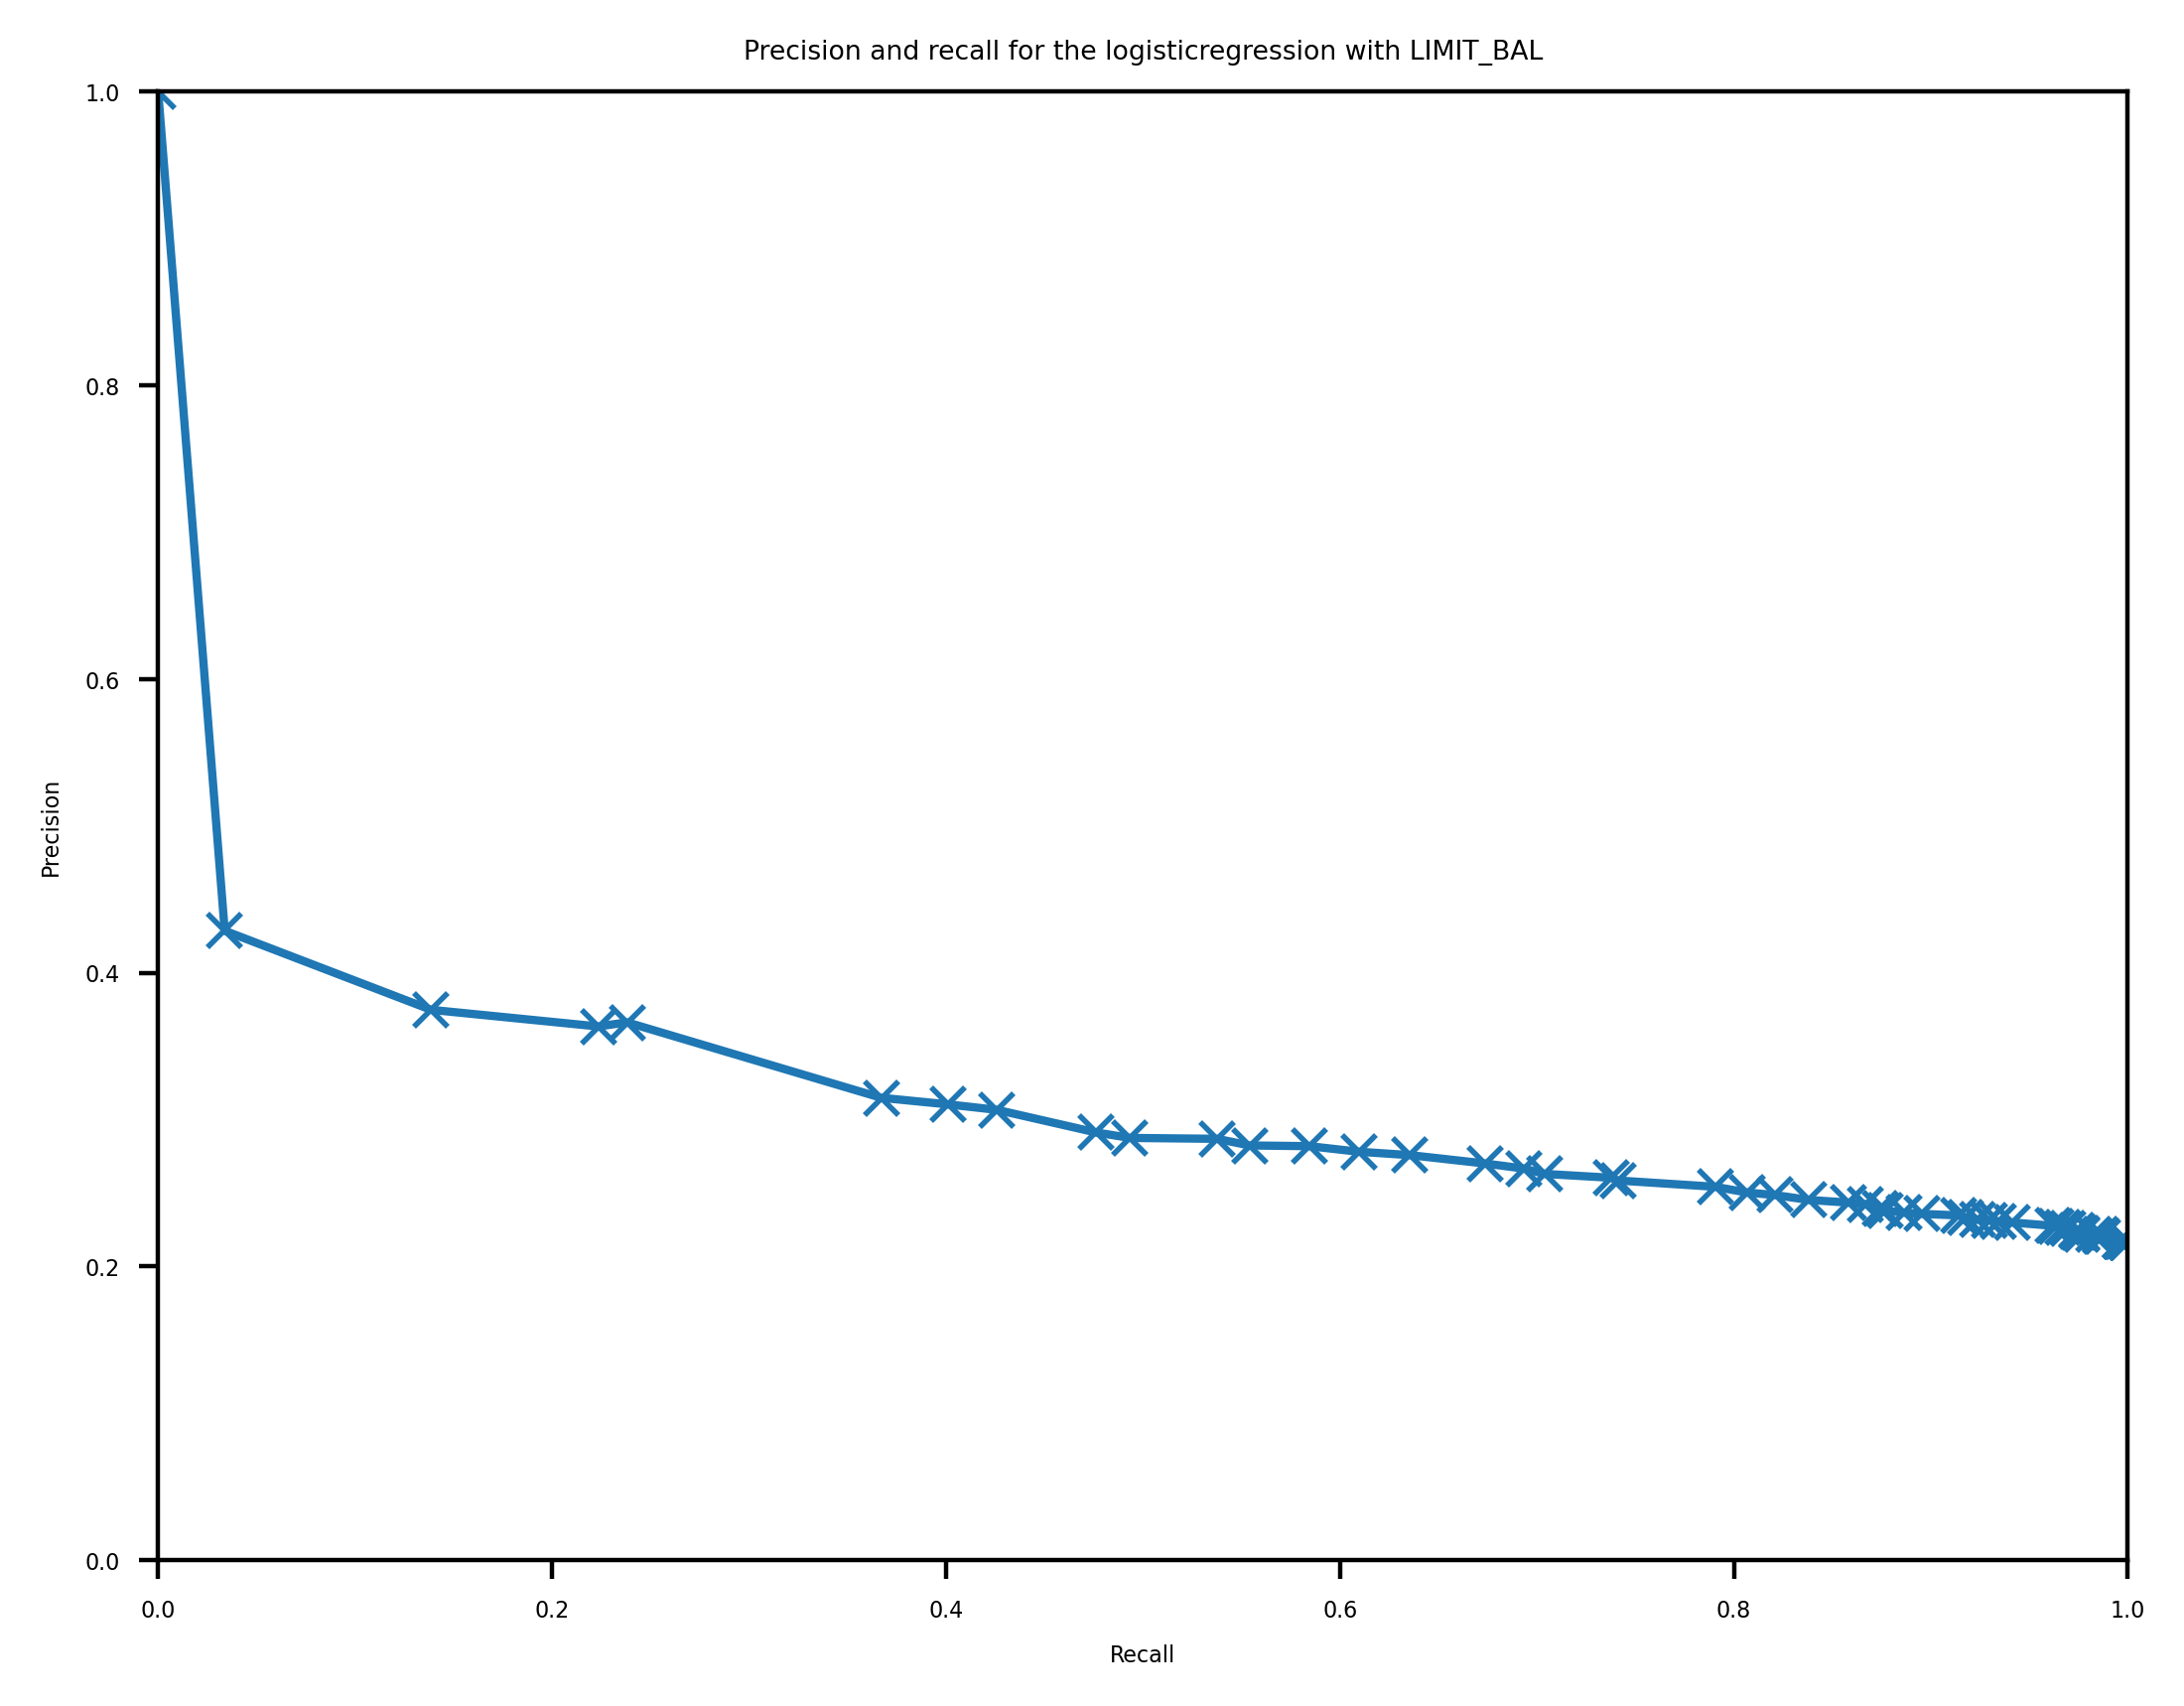

In [18]:
# Plot PRC (precision_recall_curve)
precision, recall, thresh_3 = metrics.precision_recall_curve\
                              (y_test_2,\
                               y_test_2_pred_proba[:,1])
plt.plot(recall, precision, '-x')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision and recall for the logistic'\
          'regression with LIMIT_BAL')
plt.xlim([0, 1])
plt.ylim([0, 1])

In [19]:
metrics.auc(recall, precision)

np.float64(0.31566964427378624)

In [20]:
y_train_2_pred_proba = example_lr.predict_proba(X_train_2)
metrics.roc_auc_score(y_train_2, y_train_2_pred_proba[:,1])

np.float64(0.6182918113358344)

Quantitatively, we can see that this AUC is not all that different from the test data ROC
AUC we calculated earlier. Both are about 0.62. Conceptually, what is the difference?
When we calculate this metric on the training data, we are measuring the model's
skill in predicting the same data that "taught" the model how to make predictions.
We are seeing how well the model fits the data. On the other hand, test data metrics
indicate performance on out-of-sample data the model hasn't "seen" before. If there
was much of a difference in these scores, which usually would come in the form of a
higher training score than the test score, it would indicate that while the model fits
the data well, the trained model does not generalize well to new, unseen data.
In this case, the training and test scores are similar, meaning the model does about
as well on out-of-sample data as it does on the same data used in model training